# 1. Install Necessary Libraries

In [1]:
import os
cpu_count = os.cpu_count()
print(f"Total CPU cores available: {cpu_count}")

Total CPU cores available: 2


In [3]:
# Install general stack
!pip install -q gspread pandas gensim seaborn matplotlib xgboost scikit_learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.8 MB/s eta 0:00:00


In [2]:
# Environment
import os
import joblib

# Data
import pandas as pd
import numpy as np

# Google Colab / Sheets
from google.colab import auth, drive
from google.auth import default
import gspread

# Sklearn — preprocessing & model selection
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Sklearn — metrics
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# XGBoost
from xgboost import XGBClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#GPU Acceleration (if wanted)
%load_ext cuml.accel

# 2. Authenticate and Access Google Drive + Sheets

In [5]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

In [6]:
from google.colab import drive
import os

drive.mount('/content/drive')

save_path = '/content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL3_Models_Results'
os.makedirs(save_path, exist_ok=True)
print(f"Directory ready: {save_path}")

Mounted at /content/drive
Directory ready: /content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL3_Models_Results


# 3. Import Datasets

**DBTL1 splits:**
- Raw — Train/Validate, Evaluation
- Group1 Preprocessed — Train/Validate, Evaluation
- Group2 Preprocessed — Train/Validate, Evaluation

**DBTL3 splits:**
- *Uses DBLT2 Splits*: DBTL2 Preprocessed — Train/Validate (single), Evaluation at 3 thresholds: `eval_50`, `eval_5`, `eval_1`

In [7]:
import pandas as pd

# Raw
wb_raw_eval = gc.open_by_url('https://docs.google.com/spreadsheets/d/1KsidfWCrywomIAbdlNg6Gn5rMER9E8gpI2AxGpNfjZ4/edit?usp=drive_link')
data_raw_eval = wb_raw_eval.get_worksheet(0).get_all_values()
df_raw_eval = pd.DataFrame(data_raw_eval[1:], columns=data_raw_eval[0])

wb_raw_tv = gc.open_by_url('https://docs.google.com/spreadsheets/d/1swxApDpgutQxNKr6GJHSr96PQZUxd_qcKAx8hlV7YOI/edit?usp=drive_link')
data_raw_tv = wb_raw_tv.get_worksheet(0).get_all_values()
df_raw_train_valid = pd.DataFrame(data_raw_tv[1:], columns=data_raw_tv[0])

In [9]:
# Group1
wb_g1_eval = gc.open_by_url('https://docs.google.com/spreadsheets/d/1-7gT9ZaJbaG35HpCWQqJyhFo1Vl4AfQ-HeLLSWLlhdA/edit?usp=drive_link')
data_g1_eval = wb_g1_eval.get_worksheet(0).get_all_values()
df_g1_preprocessed_eval = pd.DataFrame(data_g1_eval[1:], columns=data_g1_eval[0])

wb_g1_tv = gc.open_by_url('https://docs.google.com/spreadsheets/d/1py--oeZRWbSVVBqrsLe0WZXRqhfaS_ZcNYqHIiLOcvM/edit?usp=drive_link')
data_g1_tv = wb_g1_tv.get_worksheet(0).get_all_values()
df_g1_preprocessed_train_valid = pd.DataFrame(data_g1_tv[1:], columns=data_g1_tv[0])

In [10]:
# Group2
wb_g2_eval = gc.open_by_url('https://docs.google.com/spreadsheets/d/1j3pF9gIkk_FiLEjT6STIxELDWC1EDm8Qxur849n-VFw/edit?usp=drive_link')
data_g2_eval = wb_g2_eval.get_worksheet(0).get_all_values()
df_g2_preprocessed_eval = pd.DataFrame(data_g2_eval[1:], columns=data_g2_eval[0])

wb_g2_tv = gc.open_by_url('https://docs.google.com/spreadsheets/d/1-rdT3VXb-0fi3kP96KVL4TWRwXG-sAPWeGcilLk_fTA/edit?usp=drive_link')
data_g2_tv = wb_g2_tv.get_worksheet(0).get_all_values()
df_g2_preprocessed_train_valid = pd.DataFrame(data_g2_tv[1:], columns=data_g2_tv[0])

In [11]:
# DBTL3
wb_dbtl3_eval_50 = gc.open_by_url('https://docs.google.com/spreadsheets/d/1VwDnWLw9gLDfvNhVl1z4pIaEy7s0_MEStWZo9nuYKD4/edit?usp=drive_link')
data_dbtl3_eval_50 = wb_dbtl3_eval_50.get_worksheet(0).get_all_values()
df_dbtl3_preprocessed_eval_50 = pd.DataFrame(data_dbtl3_eval_50[1:], columns=data_dbtl3_eval_50[0])

wb_dbtl3_eval_5 = gc.open_by_url('https://docs.google.com/spreadsheets/d/1XfD7MHfxCC-C1QncX2tEQ-TnDSwEL97GyTaKMdD0I0w/edit?usp=drive_link')
data_dbtl3_eval_5 = wb_dbtl3_eval_5.get_worksheet(0).get_all_values()
df_dbtl3_preprocessed_eval_5 = pd.DataFrame(data_dbtl3_eval_5[1:], columns=data_dbtl3_eval_5[0])

wb_dbtl3_eval_1 = gc.open_by_url('https://docs.google.com/spreadsheets/d/1W13mNJYEzwJlHVUiJ5ux28kvFf-hbOLyKtFn676sCx8/edit?usp=drive_link')
data_dbtl3_eval_1 = wb_dbtl3_eval_1.get_worksheet(0).get_all_values()
df_dbtl3_preprocessed_eval_1 = pd.DataFrame(data_dbtl3_eval_1[1:], columns=data_dbtl3_eval_1[0])

wb_dbtl3_tv = gc.open_by_url('https://docs.google.com/spreadsheets/d/1w8dP9OOaHrcc1LyZfE-k7Cn9wN60m0EiFZPD6jOG9GE/edit?usp=drive_link')
data_dbtl3_tv = wb_dbtl3_tv.get_worksheet(0).get_all_values()
df_dbtl3_preprocessed_train_valid = pd.DataFrame(data_dbtl3_tv[1:], columns=data_dbtl3_tv[0])

print(f"DBTL3 Train/Valid : {len(df_dbtl3_preprocessed_train_valid)} rows")
print(f"DBTL3 Eval (50)   : {len(df_dbtl3_preprocessed_eval_50)} rows")
print(f"DBTL3 Eval (5)    : {len(df_dbtl3_preprocessed_eval_5)} rows")
print(f"DBTL3 Eval (1)    : {len(df_dbtl3_preprocessed_eval_1)} rows")

DBTL3 Train/Valid : 3200 rows
DBTL3 Eval (50)   : 800 rows
DBTL3 Eval (5)    : 421 rows
DBTL3 Eval (1)    : 404 rows


# 4. Doc2Vec Embedding

**Why Doc2Vec instead of N-Gram + TF-IDF?**

TF-IDF treats each word independently and ignores word order and semantics. **Doc2Vec** (Paragraph Vector, Le & Mikolov 2014) learns a dense, fixed-size vector for each document by training a shallow neural network to predict words from context *and* a document-level tag. Benefits:

- Word order and local context are captured
- Dense 300-dim output — no `TruncatedSVD` dimensionality reduction needed
- `infer_vector()` embeds unseen documents at eval time without re-training

| Parameter | Value | Reason |
|---|---|---|
| `vector_size` | 300 | Matches prior SVD output dim |
| `min_count` | 2 | Drop very rare tokens |
| `epochs` | 40 | Sufficient convergence for email-length docs |
| `dm` | 1 | PV-DM (Distributed Memory) architecture |

In [ ]:
import numpy as np
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from gensim.utils import simple_preprocess


def tokenize_series(text_series):
    """Lowercase-tokenize a pandas Series of strings."""
    return [simple_preprocess(str(doc)) for doc in text_series]


def train_doc2vec(train_texts, vector_size=300, min_count=2, epochs=40):
    """Train a Doc2Vec model on a list of tokenized documents."""
    tagged = [TaggedDocument(words=tokens, tags=[i])
              for i, tokens in enumerate(train_texts)]
    model = Doc2Vec(vector_size=vector_size, min_count=min_count,
                    epochs=epochs, workers=4, dm=1, seed=42)
    model.build_vocab(tagged)
    model.train(tagged, total_examples=model.corpus_count, epochs=model.epochs)
    return model


def infer_vectors(model, tokenized_docs):
    """Infer Doc2Vec vectors for a list of tokenized docs. Returns (n, vector_size) array."""
    return np.array([model.infer_vector(tokens) for tokens in tokenized_docs])

In [ ]:
print("Training Doc2Vec on Raw corpus...")
raw_train_tokens = tokenize_series(df_raw_train_valid['text'])
doc2vec_raw = train_doc2vec(raw_train_tokens)
X_raw_train_valid = infer_vectors(doc2vec_raw, raw_train_tokens)
print(f"  Raw embeddings shape: {X_raw_train_valid.shape}")

print("Training Doc2Vec on Group1 corpus...")
g1_train_tokens = tokenize_series(df_g1_preprocessed_train_valid['text'])
doc2vec_g1 = train_doc2vec(g1_train_tokens)
X_g1_train_valid = infer_vectors(doc2vec_g1, g1_train_tokens)
print(f"  Group1 embeddings shape: {X_g1_train_valid.shape}")

print("Training Doc2Vec on Group2 corpus...")
g2_train_tokens = tokenize_series(df_g2_preprocessed_train_valid['text'])
doc2vec_g2 = train_doc2vec(g2_train_tokens)
X_g2_train_valid = infer_vectors(doc2vec_g2, g2_train_tokens)
print(f"  Group2 embeddings shape: {X_g2_train_valid.shape}")

print("Training Doc2Vec on DBTL3 corpus...")
dbtl3_train_tokens = tokenize_series(df_dbtl3_preprocessed_train_valid['text'])
doc2vec_dbtl3 = train_doc2vec(dbtl3_train_tokens)
X_dbtl3_train_valid = infer_vectors(doc2vec_dbtl3, dbtl3_train_tokens)
print(f"  DBTL3 embeddings shape: {X_dbtl3_train_valid.shape}")

print("\nAll Doc2Vec models trained successfully!")

Training Doc2Vec on Raw corpus...
  Raw embeddings shape: (3200, 300)
Training Doc2Vec on Group1 corpus...
  Group1 embeddings shape: (3200, 300)
Training Doc2Vec on Group2 corpus...
  Group2 embeddings shape: (3200, 300)
Training Doc2Vec on DBTL3 corpus...
  DBTL3 embeddings shape: (3200, 300)

All Doc2Vec models trained successfully!


# 5. Label Encoding

1. **`label_generic`** → Binary: `phishing = 1`, `legit = 0`
2. **`label_specific`** → Multi-class integer encoding via `LabelEncoder`

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_raw = LabelEncoder()
y_raw_specific = le_raw.fit_transform(df_raw_train_valid['label_specific'])
y_raw_generic  = df_raw_train_valid['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0).values

le_g1 = LabelEncoder()
y_g1_specific = le_g1.fit_transform(df_g1_preprocessed_train_valid['label_specific'])
y_g1_generic  = df_g1_preprocessed_train_valid['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0).values

le_g2 = LabelEncoder()
y_g2_specific = le_g2.fit_transform(df_g2_preprocessed_train_valid['label_specific'])
y_g2_generic  = df_g2_preprocessed_train_valid['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0).values

le_dbtl3 = LabelEncoder()
y_dbtl3_specific = le_dbtl3.fit_transform(df_dbtl3_preprocessed_train_valid['label_specific'])
y_dbtl3_generic  = df_dbtl3_preprocessed_train_valid['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0).values

print("Label encoding complete.")
print(f"  DBTL3 specific classes: {le_dbtl3.classes_}")

Label encoding complete.
  DBTL3 specific classes: ['human_legit' 'human_phishing' 'llm_legit' 'llm_phishing']


# 6. Train (and Validate / Tune)

**Key change from DBTL3: threshold is now a tuned hyperparameter, not post-hoc.**

### Binary models — `TunedThresholdClassifierCV`
Each binary base model is wrapped in `TunedThresholdClassifierCV` before being passed to `GridSearchCV`. During the outer grid search, the inner `TunedThresholdClassifierCV` runs its own CV to find the decision threshold that maximises F1. The result: `model.predict()` at eval time already applies the best threshold automatically — no post-hoc sweep needed.

Param grid keys use the `estimator__` prefix to target the inner model through the wrapper.

### Multi-class models — held-out threshold split
`TunedThresholdClassifierCV` is binary-only. For multi-class, we:
1. Hold out **15%** of the training data (stratified) purely for threshold selection
2. Run `GridSearchCV` on the remaining **85%**
3. Sweep thresholds on the held-out split using the best estimator
4. Store both the model and the chosen threshold together

This keeps threshold selection completely out of the final eval set.

**Models:**
```
Logistic Regression | Gaussian NB | Linear SVM | KNN | Random Forest | AdaBoost | XGBoost
```

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split, TunedThresholdClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

skf_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Threshold candidates for multi-class held-out sweep
MULTI_THRESHOLDS = np.arange(0.05, 0.95, 0.05).round(2)

## 6.1. Organize Datasets

In [ ]:
datasets = {
    'Raw': {
        'X': X_raw_train_valid,
        'y_bin': y_raw_generic,
        'y_multi': y_raw_specific
    },
    'Group1': {
        'X': X_g1_train_valid,
        'y_bin': y_g1_generic,
        'y_multi': y_g1_specific
    },
    'Group2': {
        'X': X_g2_train_valid,
        'y_bin': y_g2_generic,
        'y_multi': y_g2_specific
    },
    'DBTL3': {
        'X': X_dbtl3_train_valid,
        'y_bin': y_dbtl3_generic,
        'y_multi': y_dbtl3_specific
    }
}

## 6.2. Define Model Grids

**Binary:** every model is wrapped with `TunedThresholdClassifierCV(scoring='f1')`. Param grid keys are prefixed with `estimator__` to pass through the wrapper to the inner model.

**Multi-class:** plain models — threshold is found separately on the held-out split.

In [ ]:
def make_tuned_binary(base_model):
    """
    Wraps a binary classifier with TunedThresholdClassifierCV.
    Uses the same 10-fold stratified CV strategy as the outer GridSearchCV
    to find the decision threshold that maximises F1.
    """
    return TunedThresholdClassifierCV(
        estimator=base_model,
        scoring='f1',
        cv=skf_strategy,
        refit=True,
        store_cv_results=True
    )


# --- BINARY MODELS ---
# All param grid keys use 'estimator__' prefix to target the inner model.
models_binary = {
    'LogisticRegression': (
        make_tuned_binary(LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)),
        {'estimator__C': [0.01, 0.1, 1, 10, 100]}
    ),
    'GaussianNB': (
        make_tuned_binary(GaussianNB()),
        {'estimator__var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5]}
    ),
    'LinearSVM': (
        make_tuned_binary(SVC(kernel='linear', probability=True, random_state=42)),
        {'estimator__C': [0.1, 1, 10]}
    ),
    'KNN': (
        make_tuned_binary(KNeighborsClassifier()),
        {'estimator__n_neighbors': [3, 5, 7], 'estimator__weights': ['uniform', 'distance']}
    ),
    'RandomForest': (
        make_tuned_binary(RandomForestClassifier(random_state=42, n_jobs=-1)),
        {'estimator__n_estimators': [100, 200], 'estimator__max_depth': [None, 20]}
    ),
    'AdaBoost': (
        make_tuned_binary(AdaBoostClassifier(random_state=42)),
        {'estimator__n_estimators': [50, 100], 'estimator__learning_rate': [0.1, 1.0]}
    ),
    'XGBoost': (
        make_tuned_binary(XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)),
        {
            'estimator__n_estimators': [100, 200],
            'estimator__learning_rate': [0.1, 0.2],
            'estimator__max_depth': [3, 6]
        }
    )
}


# --- MULTI-CLASS MODELS ---
# Plain models — threshold tuned on a held-out split inside the training loop.
models_multi = {
    'LogisticRegression': (
        LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42),
        {'C': [0.01, 0.1, 1, 10, 100]}
    ),
    'GaussianNB': (
        GaussianNB(),
        {'var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5]}
    ),
    'LinearSVM': (
        SVC(kernel='linear', probability=True, random_state=42),
        {'C': [0.1, 1, 10]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [None, 20]}
    ),
    'AdaBoost': (
        AdaBoostClassifier(random_state=42),
        {'n_estimators': [50, 100], 'learning_rate': [0.1, 1.0]}
    ),
    'XGBoost': (
        XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200], 'learning_rate': [0.1, 0.2], 'max_depth': [3, 6]}
    )
}

## 6.3. Training Loop

Each entry in `trained_models` is a dict `{'model': ..., 'threshold': ...}` for both tasks:

- **Binary:** `model` is the fitted `TunedThresholdClassifierCV`; `threshold` is `model.best_threshold_` (baked in — `model.predict()` uses it automatically)
- **Multi-class:** `model` is the best estimator from GridSearchCV; `threshold` is the value found on the held-out split

In [ ]:
trained_models = {
    'Raw':    {'Binary': {}, 'Multi': {}},
    'Group1': {'Binary': {}, 'Multi': {}},
    'Group2': {'Binary': {}, 'Multi': {}},
    'DBTL3':  {'Binary': {}, 'Multi': {}}
}

for data_name, data_dict in datasets.items():
    print(f"\n{'='*45}")
    print(f"TRAINING ON DATASET: {data_name}")
    print(f"{'='*45}")

    X_current = data_dict['X']

    # ------------------------------------------------------------------
    # BINARY — GridSearchCV over TunedThresholdClassifierCV-wrapped models
    # The inner TunedThresholdClassifierCV finds the best F1 threshold
    # via CV. The outer GridSearchCV finds the best hyperparameters.
    # ------------------------------------------------------------------
    print("\n--- Binary Classification (Generic Labels) ---")
    y_bin = data_dict['y_bin']

    for model_name, (model, param_grid) in models_binary.items():
        print(f"  Training {model_name}...")
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=skf_strategy,
            scoring='f1',      # outer CV scored on F1 to align with threshold objective
            refit=True,
            n_jobs=-1
        )
        grid.fit(X_current, y_bin)

        best_model = grid.best_estimator_       # TunedThresholdClassifierCV
        best_thresh = best_model.best_threshold_

        trained_models[data_name]['Binary'][model_name] = {
            'model': best_model,
            'threshold': best_thresh
        }
        print(f"    Best F1: {grid.best_score_:.4f} | Params: {grid.best_params_} | Threshold: {best_thresh:.3f}")

    # ------------------------------------------------------------------
    # MULTI-CLASS — GridSearchCV on 85% of data, then threshold sweep
    # on the held-out 15% to find the OVR threshold that maximises
    # macro F1. TunedThresholdClassifierCV does not support multi-class.
    # ------------------------------------------------------------------
    print("\n--- Multi-class Classification (Specific Labels) ---")
    y_multi = data_dict['y_multi']

    # Stratified 85/15 split — held-out portion used only for threshold selection
    X_train_m, X_thresh_m, y_train_m, y_thresh_m = train_test_split(
        X_current, y_multi,
        test_size=0.15, stratify=y_multi, random_state=42
    )

    for model_name, (model, param_grid) in models_multi.items():
        print(f"  Training {model_name}...")

        # Step 1: Find best hyperparameters on the 85% split
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=skf_strategy,
            scoring='f1_macro',
            refit=True,
            n_jobs=-1
        )
        grid.fit(X_train_m, y_train_m)
        best_model = grid.best_estimator_

        # Step 2: Sweep thresholds on the held-out 15% (OVR — take highest-confidence
        # class that clears the threshold; fall back to argmax if none clear it)
        y_proba_thresh = best_model.predict_proba(X_thresh_m)
        best_thresh, best_f1 = 0.5, 0.0

        for thresh in MULTI_THRESHOLDS:
            y_pred_candidate = np.array([
                np.argmax(probs) if np.max(probs) < thresh
                else np.argmax(probs * (probs >= thresh))
                for probs in y_proba_thresh
            ])
            score = f1_score(y_thresh_m, y_pred_candidate, average='macro', zero_division=0)
            if score > best_f1:
                best_f1, best_thresh = score, thresh

        trained_models[data_name]['Multi'][model_name] = {
            'model': best_model,
            'threshold': float(best_thresh)
        }
        print(f"    Best CV F1: {grid.best_score_:.4f} | Params: {grid.best_params_} | Threshold: {best_thresh:.2f} (held-out F1: {best_f1:.4f})")

print("\nAll training complete!")


TRAINING ON DATASET: Raw

--- Binary Classification (Generic Labels) ---
  Training LogisticRegression...
    Best F1: 0.8460 | Params: {'estimator__C': 10} | Threshold: 0.404
  Training GaussianNB...
    Best F1: 0.6913 | Params: {'estimator__var_smoothing': 1e-11} | Threshold: 0.061
  Training LinearSVM...


## 6.4. Save DBTL3 Assets

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

save_path = '/content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL3_Models_Results'
os.makedirs(save_path, exist_ok=True)
print(f"Directory ready: {save_path}")

In [ ]:
import joblib

# Save each model entry as {'model': ..., 'threshold': ...}
print("Saving models...")
for data_name, tasks in trained_models.items():
    for task_name, models in tasks.items():
        for model_name, entry in models.items():
            file_name = f"{data_name}_{task_name}_{model_name}.joblib"
            joblib.dump(entry, os.path.join(save_path, file_name))

print("All 56 model entries saved (4 datasets × 2 tasks × 7 models).")

In [ ]:
# Save Doc2Vec models (gensim native format) and Label Encoders
print("Saving Doc2Vec models and Label Encoders...")

doc2vec_raw.save(os.path.join(save_path,   'doc2vec_raw.model'))
doc2vec_g1.save(os.path.join(save_path,    'doc2vec_g1.model'))
doc2vec_g2.save(os.path.join(save_path,    'doc2vec_g2.model'))
doc2vec_dbtl3.save(os.path.join(save_path, 'doc2vec_dbtl3.model'))

joblib.dump(le_raw,   os.path.join(save_path, 'le_raw.joblib'))
joblib.dump(le_g1,    os.path.join(save_path, 'le_g1.joblib'))
joblib.dump(le_g2,    os.path.join(save_path, 'le_g2.joblib'))
joblib.dump(le_dbtl3, os.path.join(save_path, 'le_dbtl3.joblib'))

print("All assets saved successfully!")

# 7. Evaluation of Models

This section can be run independently in a fresh session by loading all assets from Drive.

In [12]:
from google.colab import drive
import os, joblib

drive.mount('/content/drive')
load_path = '/content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL3_Models_Results'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
from gensim.models.doc2vec import Doc2Vec

print("Loading Doc2Vec models and Label Encoders...")

doc2vec_raw   = Doc2Vec.load(os.path.join(load_path, 'doc2vec_raw.model'))
doc2vec_g1    = Doc2Vec.load(os.path.join(load_path, 'doc2vec_g1.model'))
doc2vec_g2    = Doc2Vec.load(os.path.join(load_path, 'doc2vec_g2.model'))
doc2vec_dbtl3 = Doc2Vec.load(os.path.join(load_path, 'doc2vec_dbtl3.model'))

le_raw   = joblib.load(os.path.join(load_path, 'le_raw.joblib'))
le_g1    = joblib.load(os.path.join(load_path, 'le_g1.joblib'))
le_g2    = joblib.load(os.path.join(load_path, 'le_g2.joblib'))
le_dbtl3 = joblib.load(os.path.join(load_path, 'le_dbtl3.joblib'))

print("Loaded successfully!")

Loading Doc2Vec models and Label Encoders...
Loaded successfully!


In [14]:
print("Loading all 56 model entries...")

loaded_trained_models = {
    'Raw':    {'Binary': {}, 'Multi': {}},
    'Group1': {'Binary': {}, 'Multi': {}},
    'Group2': {'Binary': {}, 'Multi': {}},
    'DBTL3':  {'Binary': {}, 'Multi': {}}
}

datasets_names = ['Raw', 'Group1', 'Group2', 'DBTL3']
task_names     = ['Binary', 'Multi']
model_names    = ['LogisticRegression', 'GaussianNB', 'LinearSVM', 'KNN', 'RandomForest', 'AdaBoost', 'XGBoost']

for data_name in datasets_names:
    for task_name in task_names:
        for model_name in model_names:
            fp = os.path.join(load_path, f"{data_name}_{task_name}_{model_name}.joblib")
            if os.path.exists(fp):
                loaded_trained_models[data_name][task_name][model_name] = joblib.load(fp)

# Alias so the eval loop below works whether run fresh (loaded) or after training
trained_models = loaded_trained_models

print("All model entries loaded into 'trained_models'!")

Loading all 56 model entries...
All model entries loaded into 'trained_models'!


## 7.1. Custom Cost Function

`Cost = (50 × False Negatives) + False Positives`

- **False Negative** — phishing email marked as legit: penalised **15×**
- **False Positive** — legit email marked as phishing: penalised **1×**



---


**Metrics:**
*    **F1 Score** — Harmonic mean of precision and recall. Macro-averaged for multi-class.

*    **ROC-AUC** — Area under the ROC curve. Threshold-independent; measures separability. OVR macro-averaged for multi-class.

*    **AUC-PR** — Area under the Precision-Recall curve. More informative than ROC-AUC under class imbalance, as it focuses on the positive (phishing) class. OVR macro-averaged for multi-class.

*    **Custom Cost** — Domain-specific penalty weighted 50x toward missed phishing (false negatives).

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, average_precision_score


def calculate_custom_cost(y_true, y_pred):
    """
    Cost = (15 * False Negatives) + False Positives
    FN: Actual Phishing (1) predicted as Legit (0) — 15x penalty
    FP: Actual Legit (0) predicted as Phishing (1) — 1x penalty
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    fn = np.sum((y_true == 1) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return (50 * fn) + fp

## 7.2. Grouping Evaluation Data

Helper functions are redefined here so this section runs cleanly in a fresh session without needing Section 4.

In [16]:
from gensim.utils import simple_preprocess


def tokenize_series(text_series):
    return [simple_preprocess(str(doc)) for doc in text_series]


def infer_vectors(model, tokenized_docs):
    return np.array([model.infer_vector(tokens) for tokens in tokenized_docs])


eval_datasets = {
    'Raw': {
        'doc2vec':   doc2vec_raw,
        'le':        le_raw,
        'eval_sets': {'eval_50': df_raw_eval}
    },
    'Group1': {
        'doc2vec':   doc2vec_g1,
        'le':        le_g1,
        'eval_sets': {'eval_50': df_g1_preprocessed_eval}
    },
    'Group2': {
        'doc2vec':   doc2vec_g2,
        'le':        le_g2,
        'eval_sets': {'eval_50': df_g2_preprocessed_eval}
    },
    'DBTL3': {
        'doc2vec':   doc2vec_dbtl3,
        'le':        le_dbtl3,
        'eval_sets': {
            'eval_50': df_dbtl3_preprocessed_eval_50,
            'eval_5':  df_dbtl3_preprocessed_eval_5,
            'eval_1':  df_dbtl3_preprocessed_eval_1
        }
    }
}

## 7.3. Evaluation Loop

**No threshold sweep here** — thresholds were fixed during training and are loaded from each model entry.

- **Binary:** `model.predict(X_test)` applies `best_threshold_` internally. `Best_Threshold` is read from `entry['threshold']`.
- **Multi-class:** predictions are generated by applying the stored `threshold` to the probability matrix directly.

ROC-AUC is always computed from raw probabilities (threshold-independent).

In [17]:
results_list = []
confusion_matrices = {}

print("Starting Evaluation on all models...\n")

for data_name, config in eval_datasets.items():
    print(f"Evaluating {data_name} Dataset...")

    doc2vec_model = config['doc2vec']
    le = config['le']

    for eval_set_name, df_eval in config['eval_sets'].items():
        print(f"  Evaluating {data_name} - {eval_set_name}...")

        # 1. Tokenize and Infer Vectors using Doc2Vec
        tokenized_eval_texts = tokenize_series(df_eval['text'])
        X_test = infer_vectors(doc2vec_model, tokenized_eval_texts)

        # 2. Encode the True Labels
        # Generic (Binary)
        y_eval_bin = df_eval['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0).values

        # Specific (Multi-class) using the pre-fitted LabelEncoder
        y_eval_multi = le.transform(df_eval['label_specific'])

        # Create mapping for Multi-class Cost calculation (converting specific back to binary just for the cost metric)
        specific_to_generic_map = {i: (1 if 'phishing' in cls_name else 0) for i, cls_name in enumerate(le.classes_)}
        y_eval_multi_mapped = np.array([specific_to_generic_map[t] for t in y_eval_multi])

        # --- Evaluate BINARY Models ---
        for model_name, entry in trained_models[data_name]['Binary'].items():
            model = entry['model']
            # For TunedThresholdClassifierCV, predict method already applies the best threshold
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1] # Probability of '1' (phishing)

            f1 = f1_score(y_eval_bin, y_pred)
            auc = roc_auc_score(y_eval_bin, y_proba)
            pr_auc = average_precision_score(y_eval_bin, y_proba)
            cost = calculate_custom_cost(y_eval_bin, y_pred)
            cm = confusion_matrix(y_eval_bin, y_pred)

            # Save results
            results_list.append({
                'Dataset': data_name, 'Eval_Set': eval_set_name, 'Task': 'Binary', 'Model': model_name,
                'F1_Score': f1, 'ROC_AUC': auc, 'AUC_PR': pr_auc, 'Custom_Cost': cost,
                'Best_Threshold': entry['threshold'] # Add the threshold to results
            })
            confusion_matrices[f"{data_name}_{eval_set_name}_Binary_{model_name}"] = cm

        # --- Evaluate MULTI-CLASS Models ---
        for model_name, entry in trained_models[data_name]['Multi'].items():
            model = entry['model']
            threshold = entry['threshold']

            y_proba = model.predict_proba(X_test) # Probabilities for all classes

            # Apply the stored threshold for multi-class prediction
            y_pred_multi_thresh = []
            for probs in y_proba:
                # If no class clears the threshold, fall back to argmax
                # Otherwise, predict the highest-confidence class that clears the threshold
                if np.max(probs) < threshold:
                    y_pred_multi_thresh.append(np.argmax(probs))
                else:
                    y_pred_multi_thresh.append(np.argmax(probs * (probs >= threshold)))
            y_pred = np.array(y_pred_multi_thresh)


            f1 = f1_score(y_eval_multi, y_pred, average='macro', zero_division=0)
            auc = roc_auc_score(y_eval_multi, y_proba, multi_class='ovr', average='macro')
            pr_auc = average_precision_score(y_eval_multi, y_proba, average='macro')

            # Calculate custom cost for multi-class by mapping predictions back to generic binary
            y_pred_mapped = np.array([specific_to_generic_map[p] for p in y_pred])
            cost = calculate_custom_cost(y_eval_multi_mapped, y_pred_mapped)
            cm = confusion_matrix(y_eval_multi, y_pred)

            # Save results
            results_list.append({
                'Dataset': data_name, 'Eval_Set': eval_set_name, 'Task': 'Multi-Class', 'Model': model_name,
                'F1_Score': f1, 'ROC_AUC': auc, 'AUC_PR': pr_auc, 'Custom_Cost': cost,
                'Best_Threshold': threshold # Add the threshold to results
            })
            confusion_matrices[f"{data_name}_{eval_set_name}_Multi_{model_name}"] = cm

print("\nEvaluation Complete!")

Starting Evaluation on all models...

Evaluating Raw Dataset...
  Evaluating Raw - eval_50...
Evaluating Group1 Dataset...
  Evaluating Group1 - eval_50...
Evaluating Group2 Dataset...
  Evaluating Group2 - eval_50...
Evaluating DBTL3 Dataset...
  Evaluating DBTL3 - eval_50...
  Evaluating DBTL3 - eval_5...
  Evaluating DBTL3 - eval_1...

Evaluation Complete!


# 8. Reporting of Results

In [ ]:
# Ensure save_path is defined whether we trained (Section 6) or loaded fresh (Section 7)
if 'save_path' not in dir():
    save_path = load_path

# Convert to DataFrame and sort to find the best models easily
results_df = pd.DataFrame(results_list)

# Sorting by Dataset, Task, and then by lowest Custom Cost
results_df = results_df.sort_values(by=['Dataset', 'Task', 'Custom_Cost', 'ROC_AUC', 'AUC_PR'], ascending=[True, True, True, False, False])


print("Saving evaluation results and confusion matrices to Shared Drive...")

# 1. Save the Master DataFrame as a CSV
csv_file_path = os.path.join(save_path, 'Master_Evaluation_Results.csv')
results_df.to_csv(csv_file_path, index=False)
print(f"Master DataFrame saved to: {csv_file_path}")

# 2. Save the Confusion Matrices dictionary
cm_file_path = os.path.join(save_path, 'All_Confusion_Matrices.joblib')
joblib.dump(confusion_matrices, cm_file_path)
print(f"Confusion Matrices dictionary saved to: {cm_file_path}")

print("\nAll evaluation artifacts successfully saved!")

## 8.1. Results DataFrame

In [20]:
results_df = pd.DataFrame(results_list)
display(results_df)

,Dataset,Eval_Set,Task,Model,F1_Score,ROC_AUC,AUC_PR,Custom_Cost,Best_Threshold
0,Raw,eval_50,Binary,LogisticRegression,0.850183,0.925806,0.923976,2622,0.444444
1,Raw,eval_50,Binary,GaussianNB,0.625137,0.593969,0.553889,5929,0.010101
2,Raw,eval_50,Binary,LinearSVM,0.865316,0.926662,0.921256,1926,0.434343
3,Raw,eval_50,Binary,KNN,0.848276,0.905331,0.870827,1651,0.333333
4,Raw,eval_50,Binary,RandomForest,0.866051,0.941009,0.938969,1341,0.467613
...,...,...,...,...,...,...,...,...,...
79,DBTL3,eval_1,Multi-Class,LinearSVM,0.504551,0.978973,0.661022,61,0.050000
80,DBTL3,eval_1,Multi-Class,KNN,0.461546,0.941849,0.544761,127,0.050000
81,DBTL3,eval_1,Multi-Class,RandomForest,0.492954,0.990310,0.844781,73,0.050000
82,DBTL3,eval_1,Multi-Class,AdaBoost,0.394188,0.935740,0.534453,131,0.050000


## 8.2. Top 3 Models (Across Different Metrics)

In [21]:
# ── AUC-PR as primary metric ──────────────────────────────────────────────────
def highlight_top_3_by_aucpr(df):
    print("🏆 TOP 3 BEST PERFORMING MODELS (Highest AUC-PR) 🏆")
    print("-" * 65)
    top_3 = df.sort_values(by=['AUC_PR', 'Custom_Cost', 'ROC_AUC'], ascending=[False, True, False]).head(3)
    top_3 = top_3.reset_index(drop=True)
    for index, row in top_3.iterrows():
        print(f"Rank {index + 1}: {row['Model']} trained on '{row['Dataset']}' ({row['Task']})")
        print(f"   -> AUC-PR:      {row['AUC_PR']:.4f}")
        print(f"   -> Custom Cost: {row['Custom_Cost']}")
        print(f"   -> ROC-AUC:     {row['ROC_AUC']:.4f}")
        print(f"   -> F1 Score:    {row['F1_Score']:.4f}\n")
    return top_3

# ── ROC-AUC as primary metric ─────────────────────────────────────────────────
def highlight_top_3_by_rocauc(df):
    print("🏆 TOP 3 BEST PERFORMING MODELS (Highest ROC-AUC) 🏆")
    print("-" * 65)
    top_3 = df.sort_values(by=['ROC_AUC', 'Custom_Cost', 'AUC_PR'], ascending=[False, True, False]).head(3)
    top_3 = top_3.reset_index(drop=True)
    for index, row in top_3.iterrows():
        print(f"Rank {index + 1}: {row['Model']} trained on '{row['Dataset']}' ({row['Task']})")
        print(f"   -> ROC-AUC:     {row['ROC_AUC']:.4f}")
        print(f"   -> Custom Cost: {row['Custom_Cost']}")
        print(f"   -> AUC-PR:      {row['AUC_PR']:.4f}")
        print(f"   -> F1 Score:    {row['F1_Score']:.4f}\n")
    return top_3

# ── F1 as primary metric ──────────────────────────────────────────────────────
def highlight_top_3_by_f1(df):
    print("🏆 TOP 3 BEST PERFORMING MODELS (Highest F1 Score) 🏆")
    print("-" * 65)
    top_3 = df.sort_values(by=['F1_Score', 'Custom_Cost', 'AUC_PR'], ascending=[False, True, False]).head(3)
    top_3 = top_3.reset_index(drop=True)
    for index, row in top_3.iterrows():
        print(f"Rank {index + 1}: {row['Model']} trained on '{row['Dataset']}' ({row['Task']})")
        print(f"   -> F1 Score:    {row['F1_Score']:.4f}")
        print(f"   -> Custom Cost: {row['Custom_Cost']}")
        print(f"   -> AUC-PR:      {row['AUC_PR']:.4f}")
        print(f"   -> ROC-AUC:     {row['ROC_AUC']:.4f}\n")
    return top_3

# ── Custom Cost as primary metric ─────────────────────────────────────────────
def highlight_top_3_by_cost(df):
    print("🏆 TOP 3 BEST PERFORMING MODELS (Lowest Custom Cost) 🏆")
    print("-" * 65)
    top_3 = df.sort_values(by=['Custom_Cost', 'AUC_PR', 'ROC_AUC'], ascending=[True, False, False]).head(3)
    top_3 = top_3.reset_index(drop=True)
    for index, row in top_3.iterrows():
        print(f"Rank {index + 1}: {row['Model']} trained on '{row['Dataset']}' ({row['Task']})")
        print(f"   -> Custom Cost: {row['Custom_Cost']}")
        print(f"   -> AUC-PR:      {row['AUC_PR']:.4f}")
        print(f"   -> ROC-AUC:     {row['ROC_AUC']:.4f}")
        print(f"   -> F1 Score:    {row['F1_Score']:.4f}\n")
    return top_3

# ── Run all four ──────────────────────────────────────────────────────────────
top3_aucpr  = highlight_top_3_by_aucpr(results_df)
top3_rocauc = highlight_top_3_by_rocauc(results_df)
top3_f1     = highlight_top_3_by_f1(results_df)
top3_cost   = highlight_top_3_by_cost(results_df)





🏆 TOP 3 BEST PERFORMING MODELS (Highest AUC-PR) 🏆
-----------------------------------------------------------------
Rank 1: XGBoost trained on 'DBTL3' (Binary)
   -> AUC-PR:      0.9685
   -> Custom Cost: 1892
   -> ROC-AUC:     0.9671
   -> F1 Score:    0.9019

Rank 2: XGBoost trained on 'Group2' (Binary)
   -> AUC-PR:      0.9676
   -> Custom Cost: 1121
   -> ROC-AUC:     0.9672
   -> F1 Score:    0.8918

Rank 3: XGBoost trained on 'Raw' (Binary)
   -> AUC-PR:      0.9655
   -> Custom Cost: 1691
   -> ROC-AUC:     0.9653
   -> F1 Score:    0.9084

🏆 TOP 3 BEST PERFORMING MODELS (Highest ROC-AUC) 🏆
-----------------------------------------------------------------
Rank 1: XGBoost trained on 'DBTL3' (Binary)
   -> ROC-AUC:     0.9950
   -> Custom Cost: 42
   -> AUC-PR:      0.5667
   -> F1 Score:    0.1600

Rank 2: XGBoost trained on 'DBTL3' (Multi-Class)
   -> ROC-AUC:     0.9941
   -> Custom Cost: 46
   -> AUC-PR:      0.8164
   -> F1 Score:    0.5454

Rank 3: RandomForest trained on 

## 8.3. DBTL3 — Performance Across the 3 Eval Sets

Pivot table comparing the same DBTL3-trained models side-by-side across `eval_50`, `eval_5`, and `eval_1`.

In [ ]:
DBTL3_df = results_df[results_df['Dataset'] == 'DBTL3'].copy()

DBTL3_pivot = DBTL3_df.pivot_table(
    index=['Task', 'Model', 'Best_Threshold'],
    columns='Eval_Set',
    values=['AUC_PR','F1_Score', 'ROC_AUC', 'Custom_Cost'],
    aggfunc='first'
)

print("DBTL3 Performance Across Eval Sets:")
display(DBTL3_pivot)

## 8.4. Confusion Matrix Visualization

Key format: `"{Dataset}_{eval_set}_{Binary|Multi}_{ModelName}"`

Examples:
- `"DBTL3_eval_50_Binary_LogisticRegression"`
- `"Group1_default_Multi_LinearSVM"`

In [ ]:
# --- Binary confusion matrix ---
matrix_key = "DBTL3_eval_50_Binary_LogisticRegression"
cm = confusion_matrices[matrix_key]

# Pull the threshold that was used for this model from results_df
thresh_used = results_df[
    (results_df['Dataset'] == 'DBTL3') &
    (results_df['Eval_Set'] == 'eval_50') &
    (results_df['Task'] == 'Binary') &
    (results_df['Model'] == 'LogisticRegression')
]['Best_Threshold'].values[0]

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit (0)', 'Phishing (1)'],
            yticklabels=['Legit (0)', 'Phishing (1)'])
plt.title(f'Confusion Matrix: {matrix_key}\n(threshold = {thresh_used})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
# --- Multi-class confusion matrix ---
matrix_key = "DBTL3_eval_50_Multi_LinearSVM"
cm = confusion_matrices[matrix_key]
class_names = le_dbtl3.classes_

thresh_used = results_df[
    (results_df['Dataset'] == 'DBTL3') &
    (results_df['Eval_Set'] == 'eval_50') &
    (results_df['Task'] == 'Multi-Class') &
    (results_df['Model'] == 'LinearSVM')
]['Best_Threshold'].values[0]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f'Confusion Matrix: {matrix_key}\n(threshold = {thresh_used})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

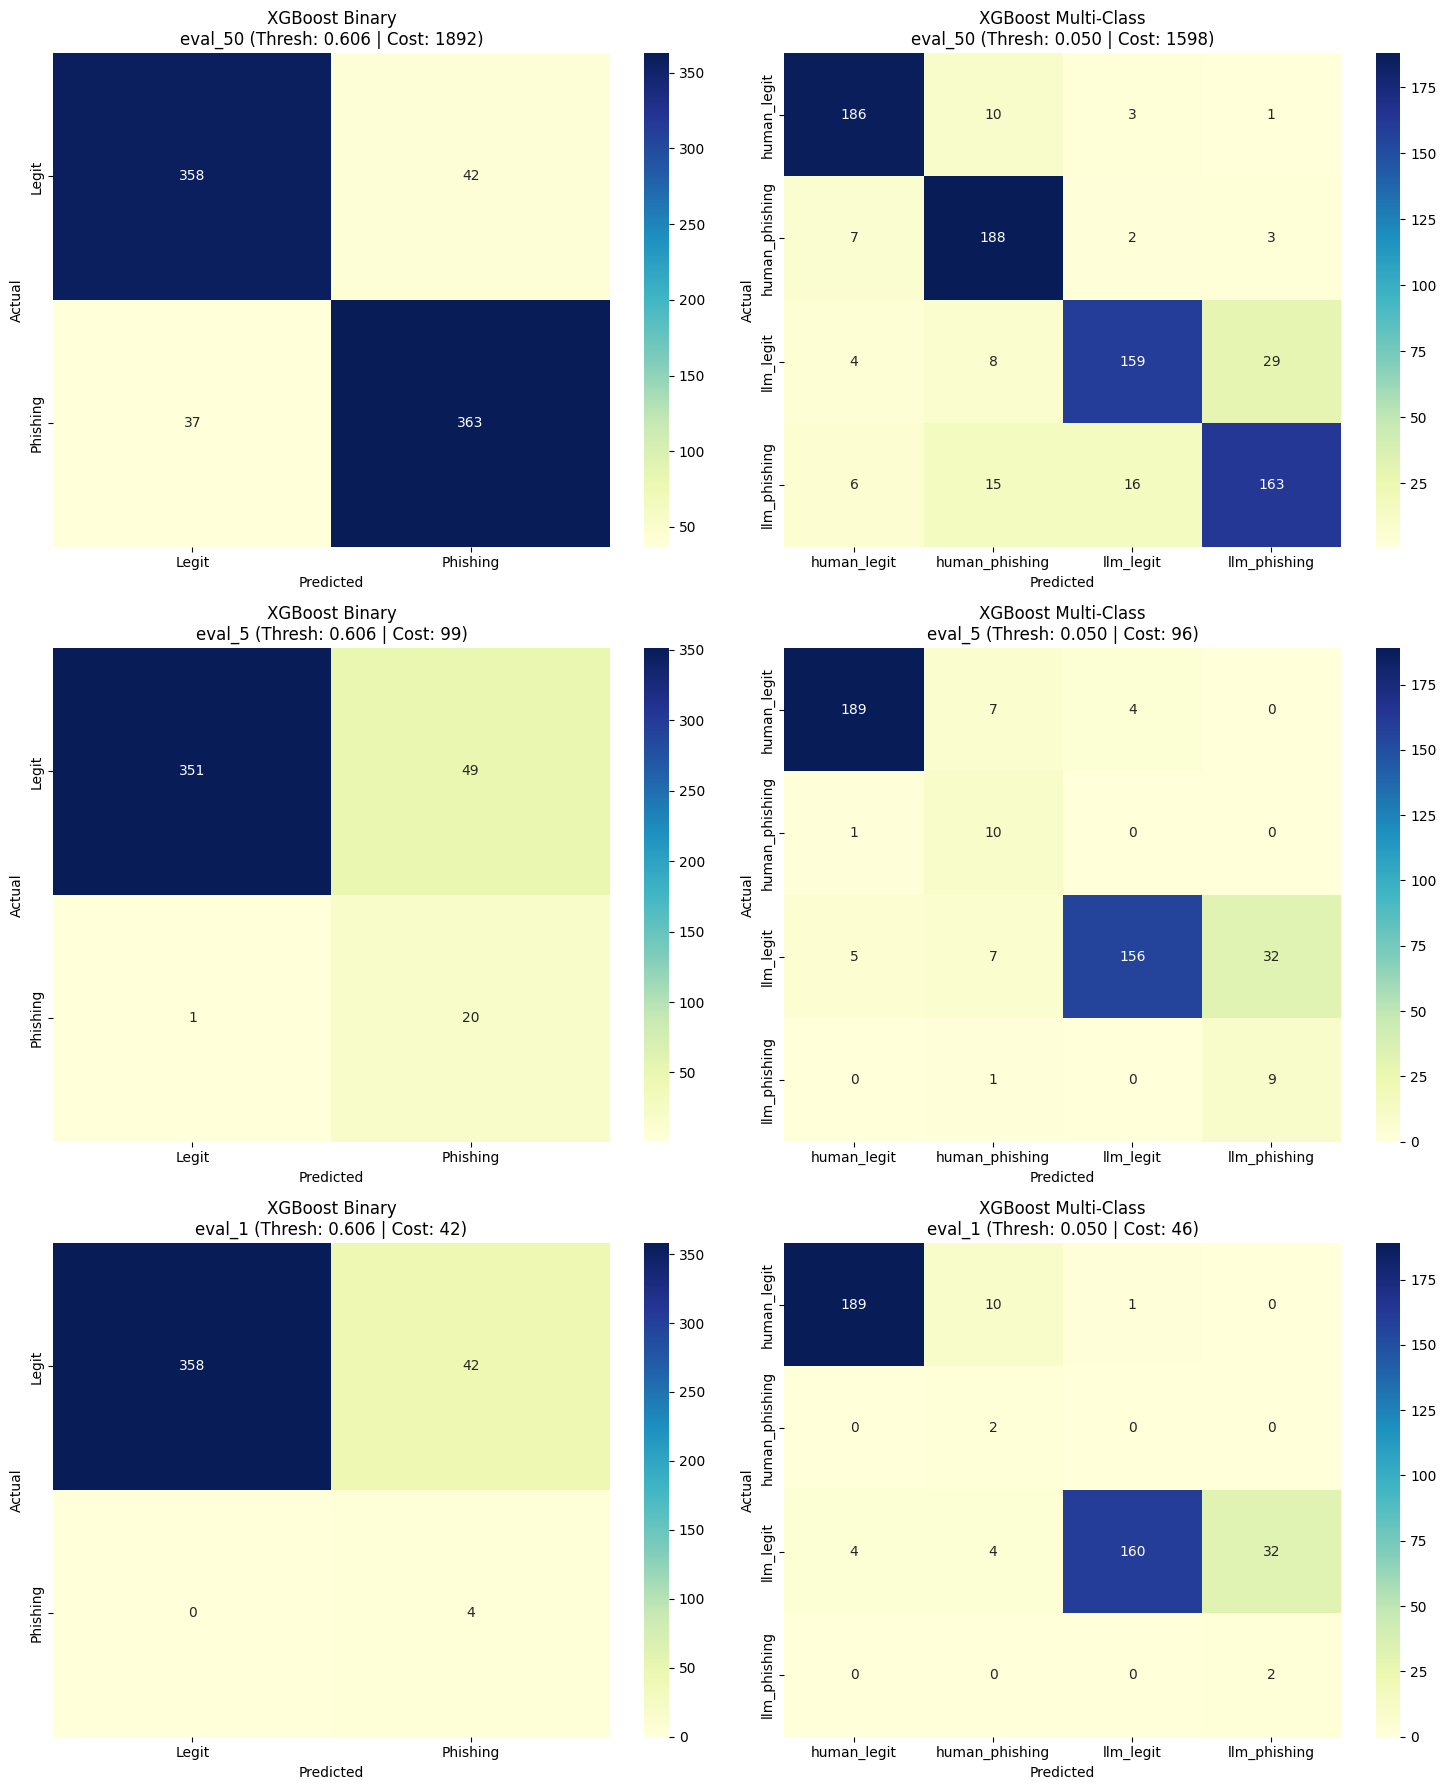

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

eval_sets = ['eval_50', 'eval_5', 'eval_1']
tasks = [('Binary', 'Binary'), ('Multi-Class', 'Multi')]
model_name = 'XGBoost'
data_name = 'DBTL3'
class_names = le_dbtl3.classes_

fig, axes = plt.subplots(3, 2, figsize=(15, 18))

for i, eval_set in enumerate(eval_sets):
    for j, (task_label, task_key) in enumerate(tasks):
        matrix_key = f"{data_name}_{eval_set}_{task_key}_{model_name}"

        if matrix_key in confusion_matrices:
            cm = confusion_matrices[matrix_key]

            # Get row for threshold and custom cost
            results_row = results_df[
                (results_df['Dataset'] == data_name) &
                (results_df['Eval_Set'] == eval_set) &
                (results_df['Task'] == task_label) &
                (results_df['Model'] == model_name)
            ]

            if not results_row.empty:
                thresh_used = results_row['Best_Threshold'].values[0]
                cost_val = results_row['Custom_Cost'].values[0]
            else:
                thresh_used = "N/A"
                cost_val = "N/A"

            sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[i, j],
                        xticklabels=['Legit', 'Phishing'] if task_key == 'Binary' else class_names,
                        yticklabels=['Legit', 'Phishing'] if task_key == 'Binary' else class_names)

            if isinstance(thresh_used, (int, float)):
                title_suffix = f"Thresh: {thresh_used:.3f} | Cost: {cost_val}"
            else:
                title_suffix = f"Thresh: {thresh_used} | Cost: {cost_val}"

            axes[i, j].set_title(f"{model_name} {task_label}\n{eval_set} ({title_suffix})")
            axes[i, j].set_ylabel('Actual')
            axes[i, j].set_xlabel('Predicted')
        else:
            axes[i, j].text(0.5, 0.5, f'Matrix not found:\n{matrix_key}',
                            ha='center', va='center')
            axes[i, j].set_title(f"{model_name} {task_label} - {eval_set}")

plt.tight_layout()
plt.show()